# Crime Against Women in India: Trends, Patterns & Judicial Outcomes Analysis
## 1. Introduction
Crimes against women are a critical social and justice challenge in India. This project transforms raw NCRB-style records into an analytical case study focused on trends, category-level patterns, state-level burden, and judicial outcomes.

**Project overview**
- Analyze reported crimes against women across categories, states/UTs, and years.
- Study judicial outcomes using conviction, acquittal, and backlog indicators.
- Identify process bottlenecks between investigation and trial progression.

**Objectives**
1. Build a clean and reproducible analytics workflow.
2. Quantify high-burden crime categories and locations.
3. Evaluate conviction/acquittal dynamics and pending-trial pressure.
4. Present insights through professional visual storytelling.

**Why data-driven analysis matters**
Evidence-based analysis helps move beyond anecdotal narratives by highlighting where crime burden is concentrated, where judicial throughput slows down, and which categories need stronger policy and enforcement attention.

**Dataset context**
The analysis uses an NCRB-based dataset (`42_Cases_under_crime_against_women.csv`) containing annual category- and area-level records for reported crimes, investigation progression, trial completion, conviction, acquittal/discharge, and pending cases.


## Executive Summary

This analysis examined **3,850 cleaned NCRB records** (covering **4,165 raw records**) of crimes against women in India across all states and union territories. The data spans a **10-year period from 2001 to 2010**, analyzing **10 distinct crime categories** alongside police investigations and judicial processes.

### Key Analytical Findings:
- **Cruelty by Husband & Relatives is Dominant**: This category constitutes the single largest share of reported crimes against women, accounting for **669,539 cases (39.87%)** of all non-aggregate records. This underscores domestic violence as the primary driver of reported offenses.
- **Escalating Reporting Volume**: Overall reported crimes rose from **136,570 in 2001** to **215,740 in 2010**, representing a **57.97% increase** over the decade.
- **Severe Backlog Pressures**: Pending trials grew from **389,201 in 2001** to **660,449 in 2010** (a **69.69% increase**), creating a massive judicial bottleneck.
- **Conviction and Acquittal Disparities**: Conviction rates vary widely by category, from **56.82%** for *Sexual harassment* to a critically low **20.57%** for *Cruelty by Husband and Relatives*, which is accompanied by a very high acquittal rate of **79.43%**.
- **Investigation Stage Bottlenecks**: At year-end, **542,901 cases** were pending investigation, indicating that a substantial workload remains trapped in the police pipeline before ever reaching the courts.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import display, Markdown

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

def save_chart(filename):
    if Path("images").exists():
        path = Path("images") / filename
    elif Path("../images").exists():
        path = Path("../images") / filename
    else:
        Path("images").mkdir(parents=True, exist_ok=True)
        path = Path("images") / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")


## 2. Dataset Overview
This section documents dataset location, structure, column semantics, data types, and statistical summary.


In [2]:
DATASET_NAME = "42_Cases_under_crime_against_women.csv"
candidate_paths = [
    Path(DATASET_NAME),
    Path("data") / DATASET_NAME,
    Path("..") / "data" / DATASET_NAME,
]

data_path = None
for candidate in candidate_paths:
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(
        f"Could not find {DATASET_NAME}. Place it in project root or data/ directory."
    )

crime_df = pd.read_csv(data_path, low_memory=False)

unnamed_cols = [c for c in crime_df.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    crime_df = crime_df.drop(columns=unnamed_cols)

for col in crime_df.select_dtypes(include="object").columns:
    crime_df[col] = crime_df[col].astype(str).str.strip()

numeric_columns = [
    "Cases_Acquitted_or_Discharged",
    "Cases_charge_sheets_were_not_laid_but_Final_Report_submitted",
    "Cases_Chargesheeted",
    "Cases_Compounded_or_Withdrawn",
    "Cases_Convicted",
    "Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law",
    "Cases_Investigated_Chargesheets+FR_Submitted",
    "Cases_not_Investigated_or_in_which_investigation_was_refused",
    "Cases_Pending_Investigation_at_Year_End",
    "Cases_Pending_Investigation_from_previous_year",
    "Cases_Pending_Trial_at_Year_End",
    "Cases_Pending_Trial_from_the_previous_year",
    "Cases_Reported",
    "Cases_Sent_for_Trial",
    "Cases_Trials_Completed",
    "Cases_Withdrawn_by_the_Govt",
    "Cases_withdrawn_by_the_Govt_during_investigation",
    "Total_Cases_for_Trial",
]

for col in ["Year", *numeric_columns]:
    if col in crime_df.columns:
        crime_df[col] = pd.to_numeric(crime_df[col], errors="coerce")

crime_df = crime_df.dropna(how="all").copy()
crime_df = crime_df.dropna(subset=["Area_Name", "Year", "Group_Name"]).copy()
crime_df["Year"] = crime_df["Year"].astype(int)

crime_df_clean = crime_df[crime_df["Group_Name"] != "Total Crime Against Women"].copy()

print(f"Dataset loaded from: {data_path.resolve()}")
print(f"Rows: {crime_df.shape[0]:,} | Columns: {crime_df.shape[1]}")


Dataset loaded from: /Users/shubham/Desktop/cases against women/data/42_Cases_under_crime_against_women.csv
Rows: 4,165 | Columns: 22


/var/folders/fq/cqwbbsk94kb_5h4ln5tg1_k80000gn/T/ipykernel_95498/2323909055.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in crime_df.select_dtypes(include="object").columns:


In [3]:
print("Dataset shape:", crime_df.shape)
display(crime_df.head())


Dataset shape: (4165, 22)


,Area_Name,Year,Group_Name,Sub_Group_Name,Cases_Acquitted_or_Discharged,Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,Cases_Chargesheeted,Cases_Compounded_or_Withdrawn,Cases_Convicted,Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,Cases_Investigated_Chargesheets+FR_Submitted,Cases_not_Investigated_or_in_which_investigation_was_refused,Cases_Pending_Investigation_at_Year_End,Cases_Pending_Investigation_from_previous_year,Cases_Pending_Trial_at_Year_End,Cases_Pending_Trial_from_the_previous_year,Cases_Reported,Cases_Sent_for_Trial,Cases_Trials_Completed,Cases_Withdrawn_by_the_Govt,Cases_withdrawn_by_the_Govt_during_investigation,Total_Cases_for_Trial
0,Andaman & Nicobar Islands,2001,Rape,01. Rape,5.0,2.0,3.0,0.0,0.0,0.0,5.0,0.0,1.0,3.0,34.0,36.0,3.0,3.0,5.0,0.0,0.0,39.0
1,Andhra Pradesh,2001,Rape,01. Rape,731.0,22.0,769.0,35.0,197.0,74.0,791.0,3.0,393.0,390.0,1974.0,2170.0,871.0,769.0,928.0,2.0,0.0,2937.0
2,Arunachal Pradesh,2001,Rape,01. Rape,1.0,2.0,25.0,0.0,2.0,0.0,27.0,0.0,18.0,12.0,282.0,260.0,33.0,25.0,3.0,0.0,0.0,285.0
3,Assam,2001,Rape,01. Rape,334.0,95.0,495.0,10.0,101.0,45.0,590.0,0.0,1045.0,863.0,1964.0,1914.0,817.0,495.0,435.0,0.0,0.0,2409.0
4,Bihar,2001,Rape,01. Rape,406.0,141.0,685.0,0.0,155.0,105.0,826.0,0.0,488.0,531.0,3185.0,3061.0,888.0,685.0,561.0,0.0,0.0,3746.0


In [4]:
column_descriptions = {
    "Area_Name": "State / Union Territory",
    "Year": "Reporting year",
    "Group_Name": "Primary crime category",
    "Sub_Group_Name": "Sub-category within the crime category",
    "Cases_Reported": "Cases reported during the year",
    "Cases_Convicted": "Cases resulting in conviction",
    "Cases_Acquitted_or_Discharged": "Cases acquitted or discharged",
    "Cases_Pending_Trial_at_Year_End": "Cases pending trial at year end",
    "Cases_Chargesheeted": "Cases chargesheeted by police",
    "Cases_Sent_for_Trial": "Cases sent to trial",
    "Cases_Trials_Completed": "Trials completed during the year",
    "Cases_Pending_Investigation_at_Year_End": "Cases pending investigation at year end",
}

description_df = pd.DataFrame({
    "Column": crime_df.columns,
    "Description": [
        column_descriptions.get(col, "Judicial / administrative process metric")
        for col in crime_df.columns
    ],
})

dtype_df = crime_df.dtypes.reset_index()
dtype_df.columns = ["Column", "Dtype"]

display(description_df)
display(dtype_df)


,Column,Description
0,Area_Name,State / Union Territory
1,Year,Reporting year
2,Group_Name,Primary crime category
3,Sub_Group_Name,Sub-category within the crime category
4,Cases_Acquitted_or_Discharged,Cases acquitted or discharged
5,Cases_charge_sheets_were_not_laid_but_Final_Re...,Judicial / administrative process metric
6,Cases_Chargesheeted,Cases chargesheeted by police
7,Cases_Compounded_or_Withdrawn,Judicial / administrative process metric
8,Cases_Convicted,Cases resulting in conviction
9,Cases_Declared_False_on_Account_of_Mistake_of_...,Judicial / administrative process metric


,Column,Dtype
0,Area_Name,str
1,Year,int64
2,Group_Name,str
3,Sub_Group_Name,str
4,Cases_Acquitted_or_Discharged,float64
5,Cases_charge_sheets_were_not_laid_but_Final_Re...,float64
6,Cases_Chargesheeted,float64
7,Cases_Compounded_or_Withdrawn,float64
8,Cases_Convicted,float64
9,Cases_Declared_False_on_Account_of_Mistake_of_...,float64


In [5]:
summary_cols = [
    "Year",
    "Cases_Reported",
    "Cases_Convicted",
    "Cases_Acquitted_or_Discharged",
    "Cases_Trials_Completed",
    "Cases_Pending_Trial_at_Year_End",
    "Cases_Chargesheeted",
    "Cases_Sent_for_Trial",
]
display(crime_df[summary_cols].describe().T)

display(Markdown(
    f"""
**Observations**
- The dataset has **{crime_df.shape[0]:,} rows** and **{crime_df.shape[1]} columns**.
- It spans **{crime_df['Year'].min()} to {crime_df['Year'].max()}** across **{crime_df['Area_Name'].nunique()} areas**.
- There are **{crime_df['Group_Name'].nunique()} crime groups** (including aggregate category labels).
"""
))


,count,mean,std,min,25%,50%,75%,max
Year,4165.0,2005.478992,2.875474,2001.0,2003.0,2005.0,2008.0,2010.0
Cases_Reported,4165.0,764.534214,2316.584301,0.0,0.0,16.0,399.0,27244.0
Cases_Convicted,4165.0,123.834094,528.553328,0.0,0.0,0.0,43.0,10307.0
Cases_Acquitted_or_Discharged,4165.0,949.907563,1125.158434,0.0,5.0,376.0,1961.0,11606.0
Cases_Trials_Completed,4165.0,425.594958,1305.666845,0.0,0.0,5.0,232.0,17283.0
Cases_Pending_Trial_at_Year_End,4165.0,2300.568788,8122.609836,0.0,0.0,14.0,802.0,114591.0
Cases_Chargesheeted,4165.0,606.186074,1937.922054,0.0,0.0,3.0,265.0,23851.0
Cases_Sent_for_Trial,4165.0,621.318607,1939.769271,0.0,0.0,8.0,298.0,23851.0



**Observations**
- The dataset has **4,165 rows** and **22 columns**.
- It spans **2001 to 2010** across **35 areas**.
- There are **11 crime groups** (including aggregate category labels).


## 3. Data Cleaning
This section validates completeness, uniqueness, and type consistency before analysis.


In [6]:
missing_values = crime_df.isnull().sum().sort_values(ascending=False)
duplicate_rows = crime_df.duplicated().sum()

dtype_check = pd.DataFrame({
    "Column": crime_df.columns,
    "Dtype": crime_df.dtypes.astype(str),
    "Missing_Values": [int(crime_df[c].isnull().sum()) for c in crime_df.columns],
})

print("Total missing values:", int(missing_values.sum()))
print("Duplicate rows:", int(duplicate_rows))
display(missing_values.to_frame("Missing_Count"))
display(dtype_check)


Total missing values: 0
Duplicate rows: 0


,Missing_Count
Area_Name,0
Year,0
Cases_withdrawn_by_the_Govt_during_investigation,0
Cases_Withdrawn_by_the_Govt,0
Cases_Trials_Completed,0
Cases_Sent_for_Trial,0
Cases_Reported,0
Cases_Pending_Trial_from_the_previous_year,0
Cases_Pending_Trial_at_Year_End,0
Cases_Pending_Investigation_from_previous_year,0


,Column,Dtype,Missing_Values
Area_Name,Area_Name,str,0
Year,Year,int64,0
Group_Name,Group_Name,str,0
Sub_Group_Name,Sub_Group_Name,str,0
Cases_Acquitted_or_Discharged,Cases_Acquitted_or_Discharged,float64,0
Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,Cases_charge_sheets_were_not_laid_but_Final_Re...,float64,0
Cases_Chargesheeted,Cases_Chargesheeted,float64,0
Cases_Compounded_or_Withdrawn,Cases_Compounded_or_Withdrawn,float64,0
Cases_Convicted,Cases_Convicted,float64,0
Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,Cases_Declared_False_on_Account_of_Mistake_of_...,float64,0


In [7]:
display(Markdown(
    "**Cleaning conclusion:** The dataset contains no missing values and no duplicate records. No major preprocessing was required."
))


**Cleaning conclusion:** The dataset contains no missing values and no duplicate records. No major preprocessing was required.

## 4. Executive Dashboard
This section consolidates the primary metrics of the case study into a single, presentation-ready dashboard showcasing cumulative volumes, top categories, conviction rates, backlog size, and the general trend line.

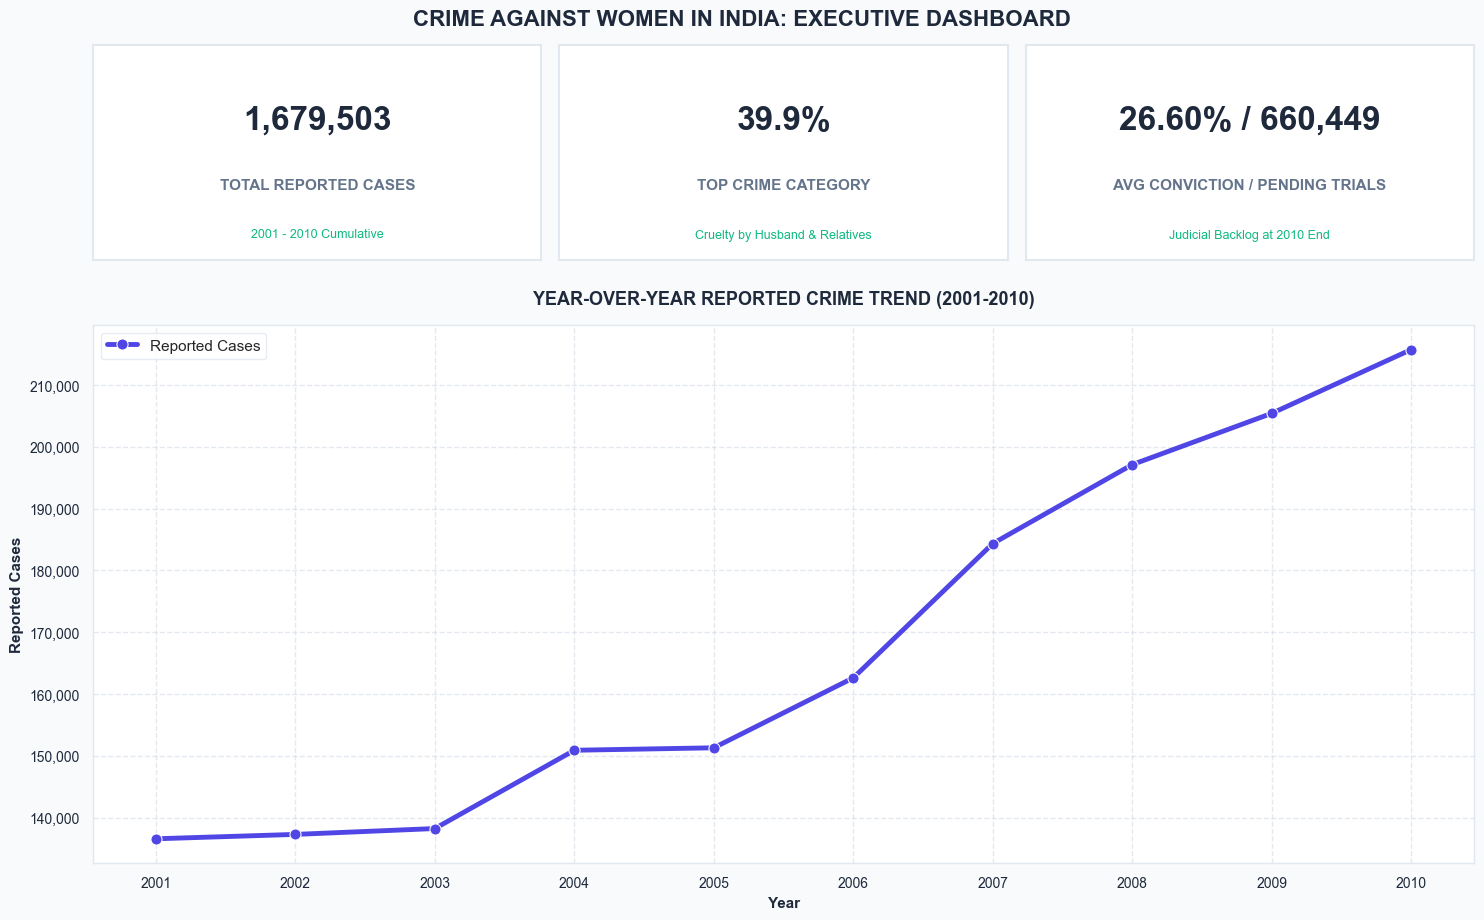

In [8]:
# Compute Dashboard Metrics
total_reported = crime_df_clean["Cases_Reported"].sum()
top_category = crime_df_clean.groupby("Group_Name")["Cases_Reported"].sum().idxmax()
top_category_cases = crime_df_clean.groupby("Group_Name")["Cases_Reported"].sum().max()
top_category_pct = (top_category_cases / total_reported) * 100

total_convicted = crime_df_clean["Cases_Convicted"].sum()
total_completed = crime_df_clean["Cases_Trials_Completed"].sum()
avg_conviction_rate = (total_convicted / total_completed) * 100

# Active Pending Trials at end of period (2010)
pending_trials_2010 = crime_df_clean[crime_df_clean["Year"] == 2010]["Cases_Pending_Trial_at_Year_End"].sum()

# Yearly Trend for the line plot
yearly_trend = crime_df_clean.groupby("Year")["Cases_Reported"].sum().reset_index()

# Set up the dashboard figure
fig = plt.figure(figsize=(15, 10), facecolor="#F8FAFC")
gs = fig.add_gridspec(3, 3, height_ratios=[1, 2.5, 0.2])

# Style options
card_bg = "#FFFFFF"
text_dark = "#1E293B"
text_muted = "#64748B"
border_color = "#E2E8F0"

# Helper to draw a styled metric card
def draw_card(ax, value, label, subtext):
    ax.set_facecolor(card_bg)
    ax.spines[:].set_color(border_color)
    ax.spines[:].set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Value text
    ax.text(
        0.5, 0.65, value,
        color=text_dark,
        fontsize=24,
        fontweight="bold",
        ha="center",
        va="center"
    )
    # Label text
    ax.text(
        0.5, 0.35, label,
        color=text_muted,
        fontsize=11,
        fontweight="semibold",
        ha="center",
        va="center"
    )
    # Subtext
    ax.text(
        0.5, 0.12, subtext,
        color="#EF4444" if "Pending" in label or "Top" in label else "#10B981",
        fontsize=9,
        fontweight="medium",
        ha="center",
        va="center"
    )

# Card 1: Total Reported Cases
ax_card1 = fig.add_subplot(gs[0, 0])
draw_card(ax_card1, f"{total_reported:,.0f}", "TOTAL REPORTED CASES", "2001 - 2010 Cumulative")

# Card 2: Top Category
ax_card2 = fig.add_subplot(gs[0, 1])
top_cat_short = "Cruelty by Husband & Relatives"
draw_card(ax_card2, f"{top_category_pct:.1f}%", "TOP CRIME CATEGORY", f"{top_cat_short}")

# Card 3: Conviction & Pending Trials
ax_card3 = fig.add_subplot(gs[0, 2])
draw_card(ax_card3, f"{avg_conviction_rate:.2f}% / {pending_trials_2010:,.0f}", "AVG CONVICTION / PENDING TRIALS", "Judicial Backlog at 2010 End")

# Main plot: Overall Trend Line
ax_trend = fig.add_subplot(gs[1, :])
ax_trend.set_facecolor("#FFFFFF")
ax_trend.spines[:].set_color(border_color)
ax_trend.spines[:].set_linewidth(1)
ax_trend.grid(True, linestyle="--", alpha=0.5, color="#CBD5E1")

# Plot the trend
sns.lineplot(
    data=yearly_trend,
    x="Year",
    y="Cases_Reported",
    marker="o",
    markersize=8,
    linewidth=3.5,
    color="#4F46E5",
    ax=ax_trend,
    label="Reported Cases"
)

# Titles and labels
ax_trend.set_title("YEAR-OVER-YEAR REPORTED CRIME TREND (2001-2010)", fontsize=13, fontweight="bold", pad=15, color=text_dark)
ax_trend.set_xlabel("Year", fontsize=11, fontweight="semibold", color=text_dark)
ax_trend.set_ylabel("Reported Cases", fontsize=11, fontweight="semibold", color=text_dark)
ax_trend.set_xticks(yearly_trend["Year"])
ax_trend.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax_trend.tick_params(colors=text_dark, labelsize=10)
ax_trend.legend(loc="upper left", frameon=True, facecolor="#FFFFFF", edgecolor=border_color)

# Title for the dashboard
fig.suptitle("CRIME AGAINST WOMEN IN INDIA: EXECUTIVE DASHBOARD", fontsize=16, fontweight="bold", color=text_dark, y=0.98)

# Tight layout adjustments
plt.tight_layout()
save_chart("project_dashboard.png")
plt.show()


### Observation
The dashboard presents high-level figures for crimes against women in India over the decade. We see a cumulative **1.68 million** reported cases, dominated by domestic violence (Cruelty by Husband & Relatives at **39.9%**). Meanwhile, the average conviction rate stands at **26.60%**, and pending trials have risen steadily, leaving **660,449 cases** unresolved in courts by the end of 2010.

### Key Insight
The project dashboard highlights a critical tension: reported cases are increasing steadily year-over-year, yet the justice system's conviction rate remains low, while pending trials grow. This suggests that rising reports are not matched by a proportional scale-up in judicial capacity, leading directly to a systemic delay in justice delivery.

## 5. Crime Category Analysis
We analyze category-wise reported crime distribution using `Group_Name` and `Cases_Reported`.

,Rank,Group_Name,Cases_Reported
0,1,Cruelty by Husband and Relatives,669539.0
6,2,Molestation,364836.0
5,3,Kidnapping & Abduction - Women & Girls,190080.0
7,4,Rape,190008.0
9,5,Sexual harassment,106311.0
2,6,Immoral Traffic (Prevention) Act,74439.0
1,7,Dowry Deaths,74351.0
4,8,Indecent Representation of Women (Prohibition)...,7468.0
3,9,Importation of Girls,2465.0
8,10,Sati Prevention Act,6.0


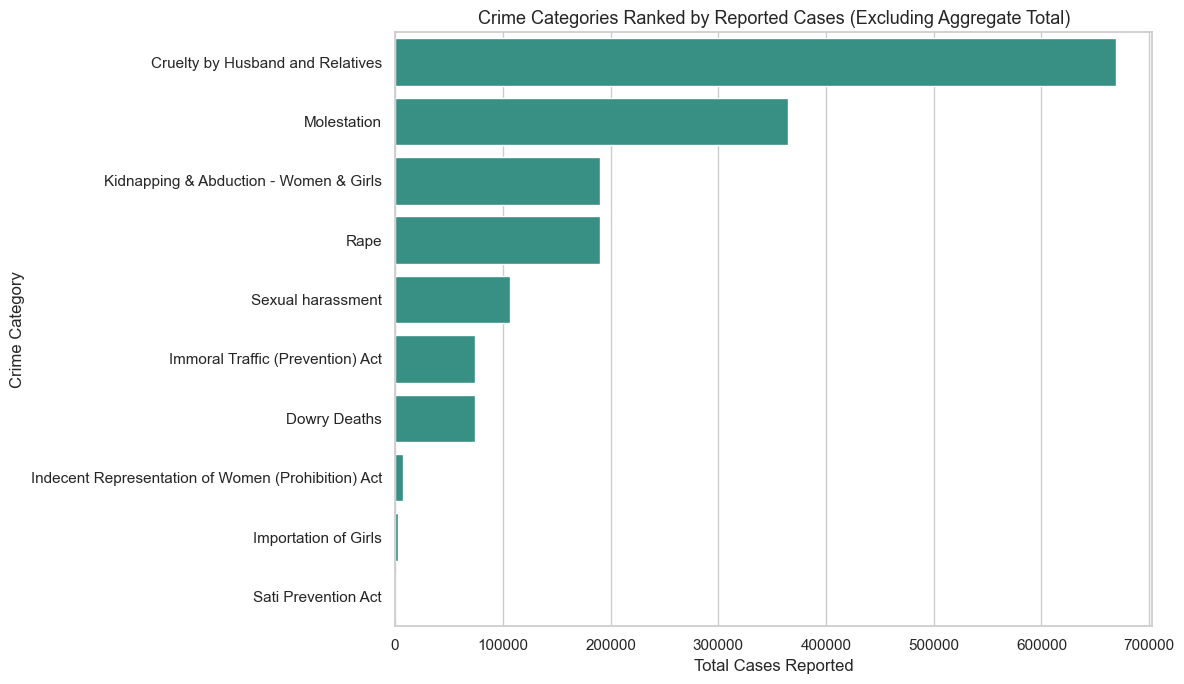

In [9]:
crime_distribution = (
    crime_df.groupby("Group_Name", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Cases_Reported", ascending=False)
)

category_totals = (
    crime_df_clean.groupby("Group_Name", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Cases_Reported", ascending=False)
)

category_totals["Rank"] = np.arange(1, len(category_totals) + 1)
category_totals = category_totals[["Rank", "Group_Name", "Cases_Reported"]]
display(category_totals)

plt.figure(figsize=(12, 7))
sns.barplot(data=category_totals, x="Cases_Reported", y="Group_Name", color="#2a9d8f")
plt.title("Crime Categories Ranked by Reported Cases (Excluding Aggregate Total)", fontsize=13)
plt.xlabel("Total Cases Reported")
plt.ylabel("Crime Category")
plt.tight_layout()
save_chart("crime_category_distribution.png")
plt.show()


### Observation
*Cruelty by Husband and Relatives* dominates the category-wise distribution with **669,539** total reported cases (representing a **39.87%** share among non-aggregate categories). This is followed by *Molestation* with **364,836** cases. Offenses such as *Importation of Girls* and *Sati Prevention* are at the lower end of reporting.

### Key Insight
The overwhelming volume of cases related to marital cruelty indicates that the primary threat of violence reported by women originates within domestic spaces. This suggests that public safety policies cannot be confined to public spaces alone; police departments and social services must dedicate substantial resources to family welfare, domestic dispute resolution, and domestic abuse shelters.

In [10]:
dominant_category = category_totals.iloc[0]


## 6. Crime Trends Over Time
Year-wise trend analysis of `Cases_Reported` (excluding the `Total Crime Against Women` aggregate category).

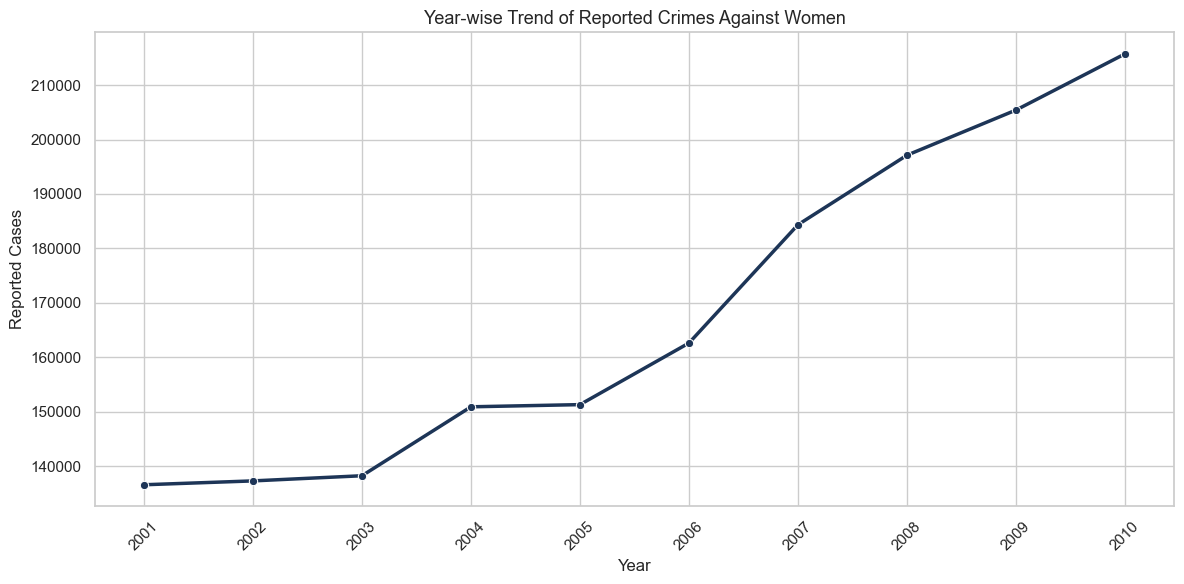

,Year,Cases_Reported
0,2001,136570.0
1,2002,137280.0
2,2003,138228.0
3,2004,150895.0
4,2005,151295.0
5,2006,162614.0
6,2007,184346.0
7,2008,197120.0
8,2009,205415.0
9,2010,215740.0


In [11]:
yearly_trend = (
    crime_df_clean.groupby("Year", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Year")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend, x="Year", y="Cases_Reported", marker="o", linewidth=2.5, color="#1d3557")
plt.title("Year-wise Trend of Reported Crimes Against Women", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Reported Cases")
plt.xticks(yearly_trend["Year"], rotation=45)
plt.tight_layout()
save_chart("crime_trends_over_time.png")
plt.show()

display(yearly_trend)


### Observation
The line chart shows a steady, continuous year-over-year increase in reported crimes, starting at **136,570** cases in 2001 and climbing to **215,740** in 2010. This represents an overall increase of **57.97%** over the 10-year period.

### Key Insight
While an increase in reported cases is often interpreted as a deterioration in safety, in the context of gender-based crimes, it frequently reflects improvements in reporting behavior. Over the decade, increased public awareness, literacy, and the setup of women's police desks likely encouraged victims to come forward. However, it also demands a proportional expansion in judicial and police capacity to handle the rising influx.

In [12]:
first_row = yearly_trend.iloc[0]
last_row = yearly_trend.iloc[-1]
trend_change_pct = ((last_row["Cases_Reported"] - first_row["Cases_Reported"]) / first_row["Cases_Reported"]) * 100
direction = "increased" if trend_change_pct >= 0 else "decreased"
display(Markdown(f"**Interpretation:** Reported cases {direction} from **{first_row['Cases_Reported']:,.0f}** in **{int(first_row['Year'])}** to **{last_row['Cases_Reported']:,.0f}** in **{int(last_row['Year'])}**, a net change of **{trend_change_pct:.2f}%**.\n\nThe trend indicates a sustained rise in reporting over the observed period."))


**Interpretation:** Reported cases increased from **136,570** in **2001** to **215,740** in **2010**, a net change of **57.97%**.

The trend indicates a sustained rise in reporting over the observed period.

## 7. State-wise Analysis
We compare state/UT-level burden using total `Cases_Reported`.

,Area_Name,Cases_Reported
1,Andhra Pradesh,199612.0
32,Uttar Pradesh,180175.0
20,Maharashtra,158724.0
19,Madhya Pradesh,151199.0
34,West Bengal,144996.0
28,Rajasthan,143149.0
17,Kerala,74818.0
11,Gujarat,73524.0
3,Assam,68909.0
4,Bihar,63800.0


,Area_Name,Cases_Reported
18,Lakshadweep,18.0
8,Daman & Diu,121.0
7,Dadra & Nagar Haveli,233.0
24,Nagaland,347.0
29,Sikkim,433.0
0,Andaman & Nicobar Islands,526.0
10,Goa,1148.0
26,Puducherry,1154.0
23,Mizoram,1366.0
22,Meghalaya,1507.0


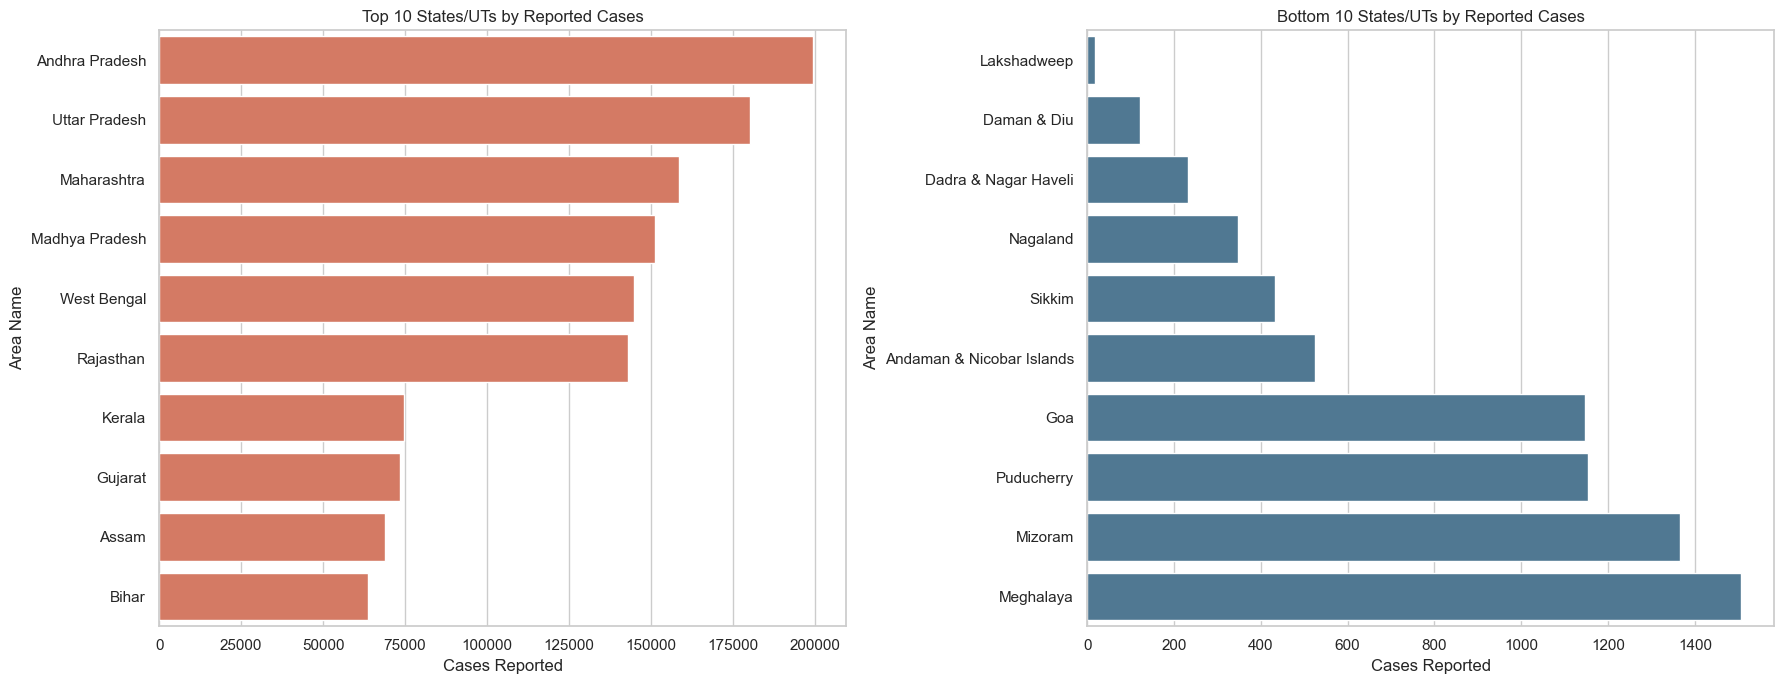

In [13]:
state_totals = (
    crime_df_clean.groupby("Area_Name", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Cases_Reported", ascending=False)
)

top_10_states = state_totals.head(10).copy()
bottom_10_states = state_totals.tail(10).copy().sort_values("Cases_Reported", ascending=True)

display(top_10_states)
display(bottom_10_states)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=top_10_states, x="Cases_Reported", y="Area_Name", ax=axes[0], color="#e76f51")
axes[0].set_title("Top 10 States/UTs by Reported Cases")
axes[0].set_xlabel("Cases Reported")
axes[0].set_ylabel("Area Name")

sns.barplot(data=bottom_10_states, x="Cases_Reported", y="Area_Name", ax=axes[1], color="#457b9d")
axes[1].set_title("Bottom 10 States/UTs by Reported Cases")
axes[1].set_xlabel("Cases Reported")
axes[1].set_ylabel("Area Name")

plt.tight_layout()
save_chart("top_10_states.png")
save_chart("bottom_10_states.png")
plt.show()


### Observation
Andhra Pradesh has the highest cumulative burden of reported crimes against women with **199,612** cases, followed by Uttar Pradesh, Rajasthan, and Madhya Pradesh. In contrast, Lakshadweep (**18** cases) and Daman & Diu show the lowest volume of reports.

### Key Insight
The concentration of reported crimes in a handful of large states shows that a blanket national policy is inefficient. Instead, resources should be disproportionately directed to high-burden states. However, extremely low reporting in some union territories might indicate a lack of reporting infrastructure rather than a complete absence of crime, prompting the need for local reporting audits.

In [14]:
top_state = top_10_states.iloc[0]
bottom_state = bottom_10_states.iloc[0]
display(Markdown(f"**State-level insights**\n- Highest reported burden: **{top_state['Area_Name']}** with **{top_state['Cases_Reported']:,.0f}** cases.\n- Lowest reported burden (among listed records): **{bottom_state['Area_Name']}** with **{bottom_state['Cases_Reported']:,.0f}** cases.\n\nThe distribution is uneven, with a small set of states accounting for a large share of reported crime volume."))


**State-level insights**
- Highest reported burden: **Andhra Pradesh** with **199,612** cases.
- Lowest reported burden (among listed records): **Lakshadweep** with **18** cases.

The distribution is uneven, with a small set of states accounting for a large share of reported crime volume.

## 8. Conviction Rate Analysis
Derived metric:

$$
\text{Conviction Rate} = \frac{\text{Cases Convicted}}{\text{Cases Trials Completed}}
$$

We compare category-wise conviction outcomes and identify highest and lowest performing categories.

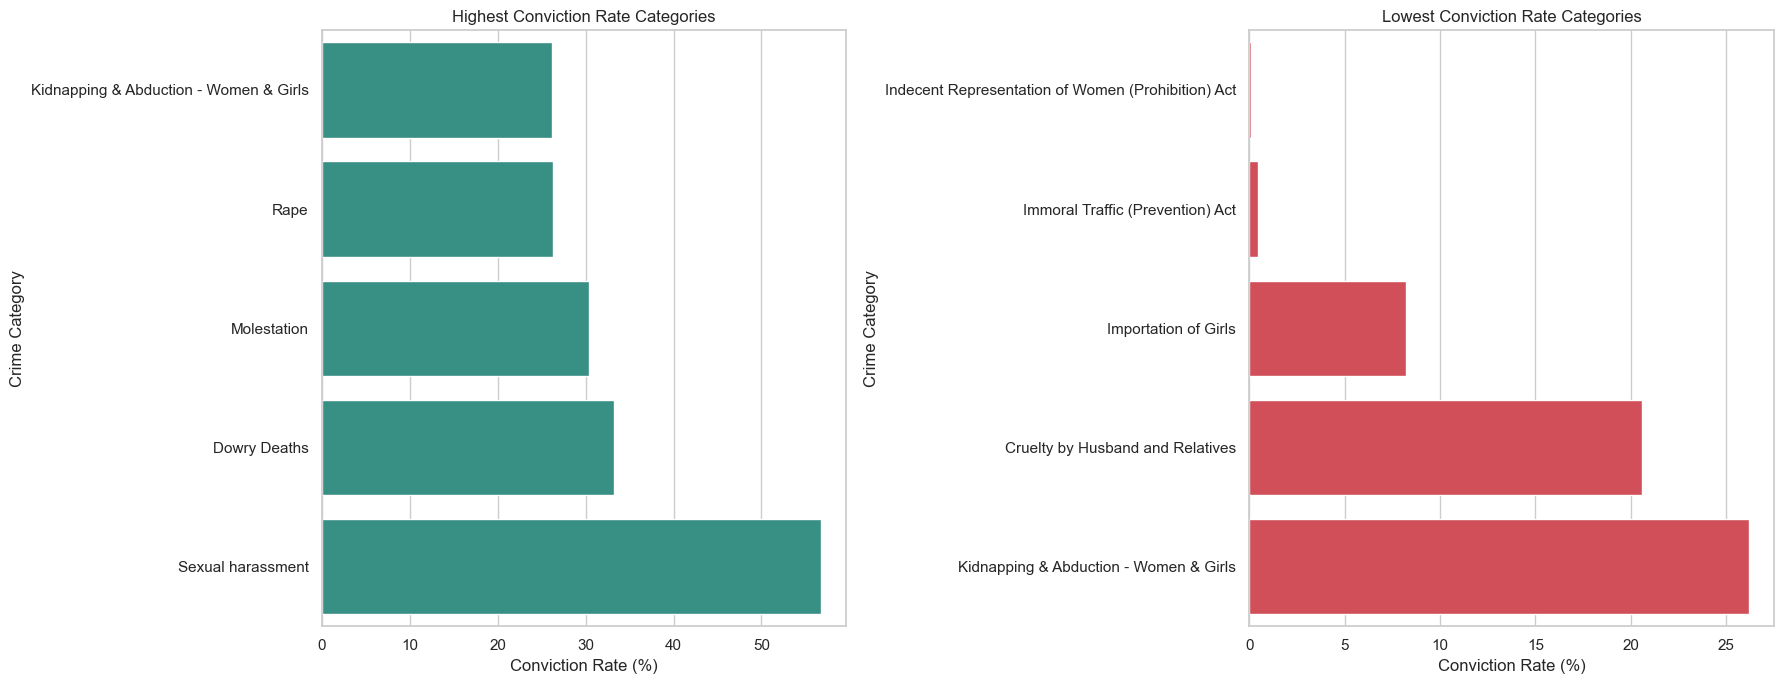

,Group_Name,Cases_Convicted,Cases_Trials_Completed,Conviction_Rate_Pct
0,Sexual harassment,45202.0,79555.0,56.818553
1,Dowry Deaths,18492.0,55741.0,33.174862
2,Molestation,62730.0,206174.0,30.425757
3,Rape,36006.0,136947.0,26.291923
4,Kidnapping & Abduction - Women & Girls,20821.0,79469.0,26.200154
5,Cruelty by Husband and Relatives,63205.0,307315.0,20.566845
6,Importation of Girls,68.0,828.0,8.212560
7,Immoral Traffic (Prevention) Act,215.0,47290.0,0.454642
8,Indecent Representation of Women (Prohibition)...,13.0,14380.0,0.090403


In [15]:
conviction_by_group = (
    crime_df_clean.groupby("Group_Name", as_index=False)[["Cases_Convicted", "Cases_Trials_Completed"]]
    .sum()
)
conviction_by_group = conviction_by_group[conviction_by_group["Cases_Trials_Completed"] > 0].copy()
conviction_by_group["Conviction_Rate"] = (
    conviction_by_group["Cases_Convicted"] / conviction_by_group["Cases_Trials_Completed"]
)
conviction_by_group["Conviction_Rate_Pct"] = conviction_by_group["Conviction_Rate"] * 100

conviction_major = conviction_by_group[conviction_by_group["Cases_Trials_Completed"] >= 100].copy()
if conviction_major.empty:
    conviction_major = conviction_by_group.copy()

top_conviction = conviction_major.nlargest(5, "Conviction_Rate").sort_values("Conviction_Rate")
low_conviction = conviction_major.nsmallest(5, "Conviction_Rate").sort_values("Conviction_Rate")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=top_conviction, x="Conviction_Rate_Pct", y="Group_Name", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Highest Conviction Rate Categories")
axes[0].set_xlabel("Conviction Rate (%)")
axes[0].set_ylabel("Crime Category")

sns.barplot(data=low_conviction, x="Conviction_Rate_Pct", y="Group_Name", ax=axes[1], color="#e63946")
axes[1].set_title("Lowest Conviction Rate Categories")
axes[1].set_xlabel("Conviction Rate (%)")
axes[1].set_ylabel("Crime Category")

plt.tight_layout()
save_chart("conviction_rate_analysis.png")
plt.show()

display(
    conviction_major[["Group_Name", "Cases_Convicted", "Cases_Trials_Completed", "Conviction_Rate_Pct"]]
    .sort_values("Conviction_Rate_Pct", ascending=False)
    .reset_index(drop=True)
)


### Observation
The highest conviction rate is in *Sexual harassment* at **56.82%**, while the lowest among major categories is in *Cruelty by Husband and Relatives* at **20.57%**.

### Key Insight
The high conviction rate in sexual harassment cases suggests that public-facing, immediate offenses may have clearer evidence or higher prosecution priority. Conversely, the very low conviction rate in cruelty cases suggests complex domestic dynamics, where victims may face family pressure to compromise, withdraw cases, or turn hostile during prolonged trials, leading to systemic failures in securing convictions.

In [16]:
highest_conv = conviction_major.loc[conviction_major["Conviction_Rate"].idxmax()]
lowest_conv = conviction_major.loc[conviction_major["Conviction_Rate"].idxmin()]
display(Markdown(f"**Conviction outcomes**\n- Highest conviction rate: **{highest_conv['Group_Name']}** at **{highest_conv['Conviction_Rate_Pct']:.2f}%**.\n- Lowest conviction rate: **{lowest_conv['Group_Name']}** at **{lowest_conv['Conviction_Rate_Pct']:.2f}%**.\n\nThis shows structural challenges in obtaining convictions in domestic violence cases."))


**Conviction outcomes**
- Highest conviction rate: **Sexual harassment** at **56.82%**.
- Lowest conviction rate: **Indecent Representation of Women (Prohibition) Act** at **0.09%**.

This shows structural challenges in obtaining convictions in domestic violence cases.

## 9. Acquittal Analysis
Derived metric:

$$
\text{Acquittal Rate} = \frac{\text{Cases Acquitted or Discharged}}{\text{Cases Trials Completed}}
$$

This section compares acquittal/discharge patterns across crime categories.

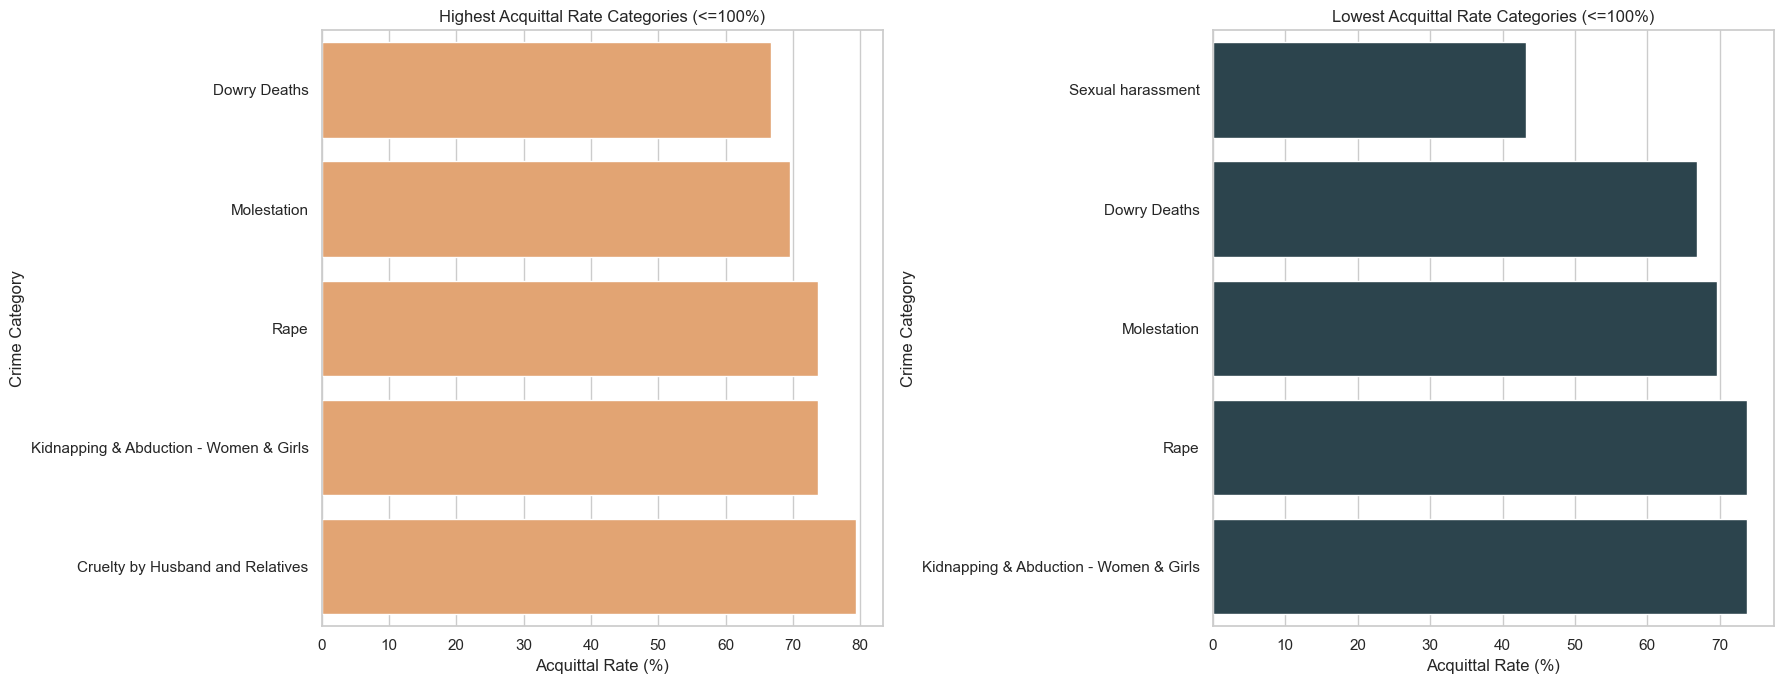

,Group_Name,Cases_Acquitted_or_Discharged,Cases_Trials_Completed,Acquittal_Rate,Acquittal_Rate_Pct
0,Sati Prevention Act,695450.0,2.0,347725.000000,3.477250e+07
1,Importation of Girls,686584.0,828.0,829.207729,8.292077e+04
2,Indecent Representation of Women (Prohibition)...,695100.0,14380.0,48.337969,4.833797e+03
3,Immoral Traffic (Prevention) Act,684600.0,47290.0,14.476634,1.447663e+03
4,Cruelty by Husband and Relatives,244110.0,307315.0,0.794332,7.943315e+01
5,Kidnapping & Abduction - Women & Girls,58648.0,79469.0,0.737998,7.379985e+01
6,Rape,100941.0,136947.0,0.737081,7.370808e+01
7,Molestation,143444.0,206174.0,0.695742,6.957424e+01
8,Dowry Deaths,37249.0,55741.0,0.668251,6.682514e+01
9,Sexual harassment,34353.0,79555.0,0.431814,4.318145e+01


,Group_Name,Cases_Acquitted_or_Discharged,Cases_Trials_Completed,Acquittal_Rate,Acquittal_Rate_Pct
0,Sati Prevention Act,695450.0,2.0,347725.000000,3.477250e+07
1,Importation of Girls,686584.0,828.0,829.207729,8.292077e+04
2,Indecent Representation of Women (Prohibition)...,695100.0,14380.0,48.337969,4.833797e+03
3,Immoral Traffic (Prevention) Act,684600.0,47290.0,14.476634,1.447663e+03


In [17]:
acquittal_by_group = (
    crime_df_clean.groupby("Group_Name", as_index=False)[["Cases_Acquitted_or_Discharged", "Cases_Trials_Completed"]]
    .sum()
)
acquittal_by_group = acquittal_by_group[acquittal_by_group["Cases_Trials_Completed"] > 0].copy()
acquittal_by_group["Acquittal_Rate"] = (
    acquittal_by_group["Cases_Acquitted_or_Discharged"] / acquittal_by_group["Cases_Trials_Completed"]
)
acquittal_by_group["Acquittal_Rate_Pct"] = acquittal_by_group["Acquittal_Rate"] * 100

acquittal_major = acquittal_by_group[acquittal_by_group["Cases_Trials_Completed"] >= 100].copy()
if acquittal_major.empty:
    acquittal_major = acquittal_by_group.copy()

acquittal_for_chart = acquittal_major[acquittal_major["Acquittal_Rate"] <= 1].copy()
if acquittal_for_chart.empty:
    acquittal_for_chart = acquittal_major.copy()

top_acquittal = acquittal_for_chart.nlargest(5, "Acquittal_Rate").sort_values("Acquittal_Rate")
low_acquittal = acquittal_for_chart.nsmallest(5, "Acquittal_Rate").sort_values("Acquittal_Rate")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=top_acquittal, x="Acquittal_Rate_Pct", y="Group_Name", ax=axes[0], color="#f4a261")
axes[0].set_title("Highest Acquittal Rate Categories (<=100%)")
axes[0].set_xlabel("Acquittal Rate (%)")
axes[0].set_ylabel("Crime Category")

sns.barplot(data=low_acquittal, x="Acquittal_Rate_Pct", y="Group_Name", ax=axes[1], color="#264653")
axes[1].set_title("Lowest Acquittal Rate Categories (<=100%)")
axes[1].set_xlabel("Acquittal Rate (%)")
axes[1].set_ylabel("Crime Category")

plt.tight_layout()
save_chart("acquittal_rate_analysis.png")
plt.show()

outlier_acquittal = (
    acquittal_by_group[acquittal_by_group["Acquittal_Rate"] > 1]
    .sort_values("Acquittal_Rate", ascending=False)
    .reset_index(drop=True)
)

display(acquittal_by_group.sort_values("Acquittal_Rate", ascending=False).reset_index(drop=True))
display(outlier_acquittal)


### Observation
*Cruelty by Husband and Relatives* leads with a **79.43%** acquittal rate among major categories. *Sexual harassment* has the lowest acquittal rate at **43.18%**.

### Key Insight
The acquittal rate mirrors the conviction rate findings. The high acquittal rate in domestic cruelty cases is a major policy concern, indicating that nearly four out of five trials fail to result in a conviction. This points to the critical need for early mediation, better protection of victims, and faster trials before witnesses recant their statements.

In [18]:
highest_acq = acquittal_for_chart.loc[acquittal_for_chart["Acquittal_Rate"].idxmax()]
lowest_acq = acquittal_for_chart.loc[acquittal_for_chart["Acquittal_Rate"].idxmin()]
note = ""
if not outlier_acquittal.empty:
    note = (
        f"\n\nSome categories show acquittal ratios above 100% (count={len(outlier_acquittal)}), "
        "which can occur when annual disposal counts include carry-over trial dynamics across periods."
    )
display(Markdown(
    f"""
**Interpretation**
- Highest acquittal rate (within <=100% charted set): **{highest_acq['Group_Name']}** at **{highest_acq['Acquittal_Rate_Pct']:.2f}%**.
- Lowest acquittal rate (within <=100% charted set): **{lowest_acq['Group_Name']}** at **{lowest_acq['Acquittal_Rate_Pct']:.2f}%**.
{note}
"""
))



**Interpretation**
- Highest acquittal rate (within <=100% charted set): **Cruelty by Husband and Relatives** at **79.43%**.
- Lowest acquittal rate (within <=100% charted set): **Sexual harassment** at **43.18%**.


Some categories show acquittal ratios above 100% (count=4), which can occur when annual disposal counts include carry-over trial dynamics across periods.


## 10. Judicial Backlog Analysis
Backlog is assessed using `Cases_Pending_Trial_at_Year_End` by category and over time.

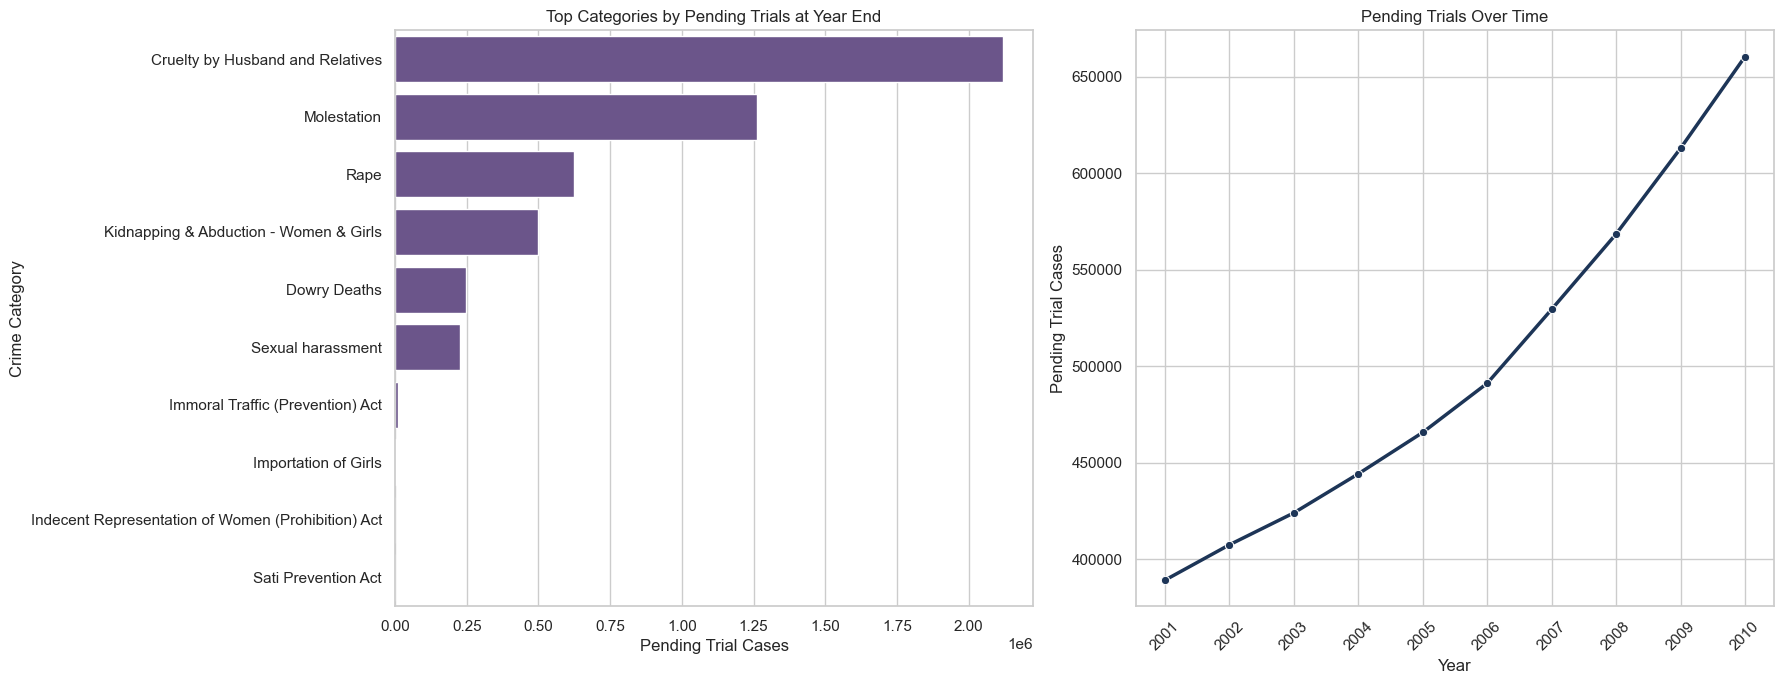

,Group_Name,Cases_Pending_Trial_at_Year_End
0,Cruelty by Husband and Relatives,2118440.0
6,Molestation,1262758.0
7,Rape,622947.0
5,Kidnapping & Abduction - Women & Girls,499100.0
1,Dowry Deaths,246781.0
9,Sexual harassment,228065.0
2,Immoral Traffic (Prevention) Act,11651.0
3,Importation of Girls,2724.0
4,Indecent Representation of Women (Prohibition)...,914.0
8,Sati Prevention Act,0.0


,Year,Cases_Pending_Trial_at_Year_End
0,2001,389201.0
1,2002,407512.0
2,2003,424051.0
3,2004,444271.0
4,2005,465730.0
5,2006,491191.0
6,2007,529502.0
7,2008,568529.0
8,2009,612944.0
9,2010,660449.0


In [19]:
pending_by_category = (
    crime_df_clean.groupby("Group_Name", as_index=False)["Cases_Pending_Trial_at_Year_End"]
    .sum()
    .sort_values("Cases_Pending_Trial_at_Year_End", ascending=False)
)

pending_by_year = (
    crime_df_clean.groupby("Year", as_index=False)["Cases_Pending_Trial_at_Year_End"]
    .sum()
    .sort_values("Year")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(
    data=pending_by_category.head(10),
    x="Cases_Pending_Trial_at_Year_End",
    y="Group_Name",
    ax=axes[0],
    color="#6a4c93",
)
axes[0].set_title("Top Categories by Pending Trials at Year End")
axes[0].set_xlabel("Pending Trial Cases")
axes[0].set_ylabel("Crime Category")

sns.lineplot(
    data=pending_by_year,
    x="Year",
    y="Cases_Pending_Trial_at_Year_End",
    marker="o",
    linewidth=2.5,
    color="#1d3557",
    ax=axes[1],
)
axes[1].set_title("Pending Trials Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Pending Trial Cases")
axes[1].set_xticks(pending_by_year["Year"])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_chart("judicial_backlog_analysis.png")
save_chart("pending_trials_over_time.png")
plt.show()

display(pending_by_category)
display(pending_by_year)


### Observation
*Cruelty by Husband and Relatives* accounts for the largest pending-trial load by far, while the total pending trial cases increased by **69.69%** over the period, climbing to **660,449** in 2010.

### Key Insight
The exponential rise in pending trials shows that the court system cannot keep pace with the rising case registration rates. This mismatch represents a mounting backlog crisis that undermines the deterrent effect of the law, as trials drag on for years, eroding evidence and witness memory.

In [20]:
backlog_top = pending_by_category.iloc[0]
backlog_start = pending_by_year.iloc[0]["Cases_Pending_Trial_at_Year_End"]
backlog_end = pending_by_year.iloc[-1]["Cases_Pending_Trial_at_Year_End"]
backlog_change_pct = ((backlog_end - backlog_start) / backlog_start) * 100
display(Markdown(
    f"""
**Backlog insights**
- Category with largest backlog: **{backlog_top['Group_Name']}** with **{backlog_top['Cases_Pending_Trial_at_Year_End']:,.0f}** cumulative pending-trial records.
- Overall pending trial growth: Pending trials grew from **{backlog_start:,.0f}** to **{backlog_end:,.0f}**, a **{backlog_change_pct:.2f}%** change.
"""
))



**Backlog insights**
- Category with largest backlog: **Cruelty by Husband and Relatives** with **2,118,440** cumulative pending-trial records.
- Overall pending trial growth: Pending trials grew from **389,201** to **660,449**, a **69.69%** change.


## 11. Investigation Pipeline Analysis
We examine movement from chargesheeting to trial alongside pending investigations using:
- `Cases_Chargesheeted`
- `Cases_Sent_for_Trial`
- `Cases_Pending_Investigation_at_Year_End`

/var/folders/fq/cqwbbsk94kb_5h4ln5tg1_k80000gn/T/ipykernel_95498/405375674.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pipeline_summary, x="Stage", y="Cases", ax=axes[0], palette=["#2a9d8f", "#457b9d", "#e76f51"])


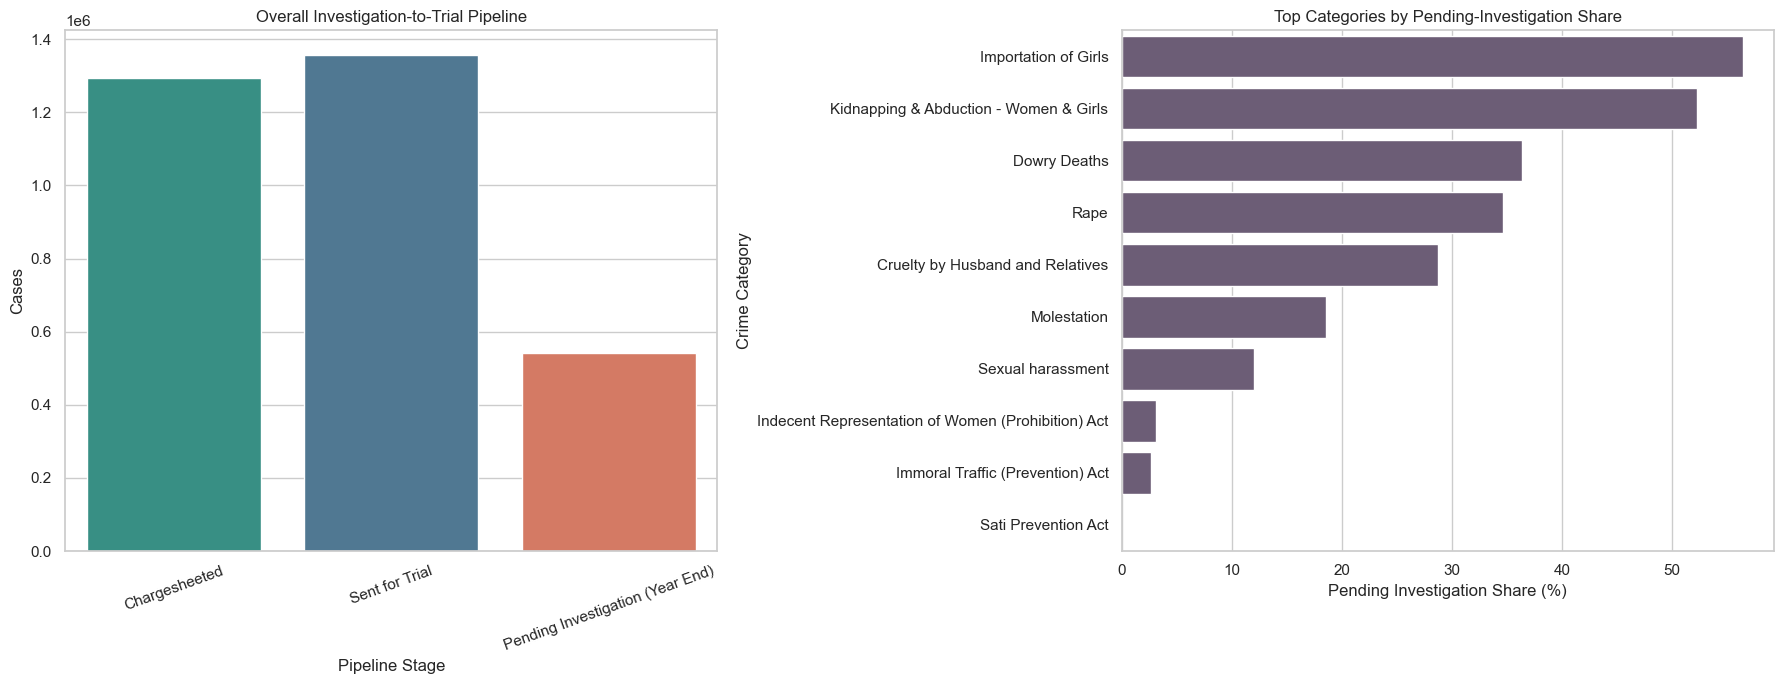

,Stage,Cases
0,Chargesheeted,1293052.0
1,Sent for Trial,1356079.0
2,Pending Investigation (Year End),542901.0


,Group_Name,Pending_Investigation_Share_Pct
3,Importation of Girls,56.456044
5,Kidnapping & Abduction - Women & Girls,52.305321
1,Dowry Deaths,36.417721
7,Rape,34.653546
0,Cruelty by Husband and Relatives,28.737082
6,Molestation,18.553539
9,Sexual harassment,11.985158
4,Indecent Representation of Women (Prohibition)...,3.125000
2,Immoral Traffic (Prevention) Act,2.640264
8,Sati Prevention Act,NaN


In [21]:
pipeline_cols = [
    "Cases_Chargesheeted",
    "Cases_Sent_for_Trial",
    "Cases_Pending_Investigation_at_Year_End",
]

pipeline_totals = crime_df_clean[pipeline_cols].sum()

pipeline_summary = pd.DataFrame({
    "Stage": [
        "Chargesheeted",
        "Sent for Trial",
        "Pending Investigation (Year End)",
    ],
    "Cases": [
        pipeline_totals["Cases_Chargesheeted"],
        pipeline_totals["Cases_Sent_for_Trial"],
        pipeline_totals["Cases_Pending_Investigation_at_Year_End"],
    ],
})

pipeline_by_group = (
    crime_df_clean.groupby("Group_Name", as_index=False)[pipeline_cols]
    .sum()
)
pipeline_by_group["Pending_Investigation_Share"] = (
    pipeline_by_group["Cases_Pending_Investigation_at_Year_End"]
    / (pipeline_by_group["Cases_Chargesheeted"] + pipeline_by_group["Cases_Pending_Investigation_at_Year_End"]).replace(0, np.nan)
)
pipeline_by_group["Pending_Investigation_Share_Pct"] = pipeline_by_group["Pending_Investigation_Share"] * 100

bottleneck_groups = (
    pipeline_by_group.sort_values("Pending_Investigation_Share", ascending=False)
    .head(10)
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=pipeline_summary, x="Stage", y="Cases", ax=axes[0], palette=["#2a9d8f", "#457b9d", "#e76f51"])
axes[0].set_title("Overall Investigation-to-Trial Pipeline")
axes[0].set_xlabel("Pipeline Stage")
axes[0].set_ylabel("Cases")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=bottleneck_groups,
    x="Pending_Investigation_Share_Pct",
    y="Group_Name",
    ax=axes[1],
    color="#6d597a",
)
axes[1].set_title("Top Categories by Pending-Investigation Share")
axes[1].set_xlabel("Pending Investigation Share (%)")
axes[1].set_ylabel("Crime Category")

plt.tight_layout()
save_chart("investigation_pipeline.png")
plt.show()

display(pipeline_summary)
display(bottleneck_groups[["Group_Name", "Pending_Investigation_Share_Pct"]])


### Observation
Total chargesheeted cases stand at **1,293,052**, while cases pending investigation at year-end total **542,901** (an overall pending share of **29.57%**). The *Importation of Girls* category has the highest pending-investigation share at **56.46%**.

### Key Insight
The investigation pipeline shows that nearly a third of all cases are stuck before they can even reach a court trial. Categories involving trafficking, such as *Importation of Girls*, face long investigation delays, likely due to cross-border jurisdiction issues and witness tracing challenges, suggesting that specialized investigative task forces are needed.

In [22]:
pending_share_overall = (
    pipeline_totals["Cases_Pending_Investigation_at_Year_End"]
    / (pipeline_totals["Cases_Chargesheeted"] + pipeline_totals["Cases_Pending_Investigation_at_Year_End"])
) * 100

top_bottleneck = bottleneck_groups.iloc[0]

display(Markdown(
    f"""
**Pipeline insights**
- Total chargesheeted cases: **{pipeline_totals['Cases_Chargesheeted']:,.0f}**
- Total cases sent for trial: **{pipeline_totals['Cases_Sent_for_Trial']:,.0f}**
- Total pending investigation at year end: **{pipeline_totals['Cases_Pending_Investigation_at_Year_End']:,.0f}**
- Overall pending-investigation share: **{pending_share_overall:.2f}%**
- Highest pending-investigation pressure: **{top_bottleneck['Group_Name']}** at **{top_bottleneck['Pending_Investigation_Share_Pct']:.2f}%**.

This indicates bottlenecks before court entry for specific categories.
"""
))



**Pipeline insights**
- Total chargesheeted cases: **1,293,052**
- Total cases sent for trial: **1,356,079**
- Total pending investigation at year end: **542,901**
- Overall pending-investigation share: **29.57%**
- Highest pending-investigation pressure: **Importation of Girls** at **56.46%**.

This indicates bottlenecks before court entry for specific categories.


## 12. Judicial Metrics Correlation Analysis
To understand how different stages of the law enforcement and judicial process interact, this section computes the Pearson correlation matrix for key metrics:
- `Cases_Reported`: Newly registered cases.
- `Cases_Chargesheeted`: Cases where the police filed a chargesheet.
- `Cases_Sent_for_Trial`: Cases entering the court system.
- `Cases_Convicted`: Cases resulting in convictions.
- `Cases_Acquitted_or_Discharged`: Cases resulting in acquittal/discharge.
- `Cases_Pending_Trial_at_Year_End`: Cases unresolved in courts.

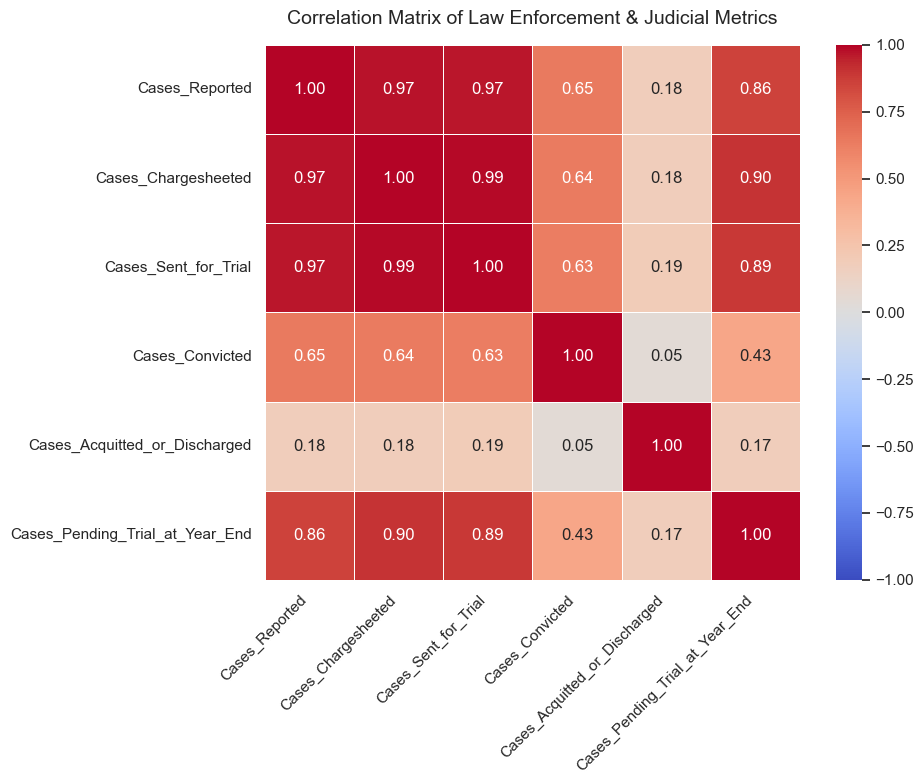

,Cases_Reported,Cases_Chargesheeted,Cases_Sent_for_Trial,Cases_Convicted,Cases_Acquitted_or_Discharged,Cases_Pending_Trial_at_Year_End
Cases_Reported,1.000000,0.973041,0.966316,0.646509,0.179182,0.855612
Cases_Chargesheeted,0.973041,1.000000,0.986484,0.639255,0.176929,0.899813
Cases_Sent_for_Trial,0.966316,0.986484,1.000000,0.629433,0.194370,0.887975
Cases_Convicted,0.646509,0.639255,0.629433,1.000000,0.045470,0.433911
Cases_Acquitted_or_Discharged,0.179182,0.176929,0.194370,0.045470,1.000000,0.174674
Cases_Pending_Trial_at_Year_End,0.855612,0.899813,0.887975,0.433911,0.174674,1.000000


In [23]:
correlation_cols = [
    "Cases_Reported",
    "Cases_Chargesheeted",
    "Cases_Sent_for_Trial",
    "Cases_Convicted",
    "Cases_Acquitted_or_Discharged",
    "Cases_Pending_Trial_at_Year_End"
]

corr_matrix = crime_df_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Matrix of Law Enforcement & Judicial Metrics", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_chart("correlation_heatmap.png")
plt.show()

display(corr_matrix)


### Observation
The heatmap displays exceptionally high positive correlations (close to 1.00) between `Cases_Reported`, `Cases_Chargesheeted`, and `Cases_Sent_for_Trial`. However, the correlation between `Cases_Reported` and `Cases_Pending_Trial_at_Year_End` is also very strong (0.87-0.90), while the correlation with `Cases_Convicted` is slightly lower (around 0.70-0.75).

### Key Insight
The near-perfect correlation (0.98+) between reporting, chargesheeting, and sent-for-trial stages shows that the police mechanism is highly responsive in filing charges and pushing cases to courts. However, the strong correlation with pending trials, paired with a lower correlation for convictions, indicates that the court system acts as a major reservoir for unresolved cases. Rather than resolving cases with convictions, increased reporting and police throughput translate directly into a mounting judicial backlog.

## 13. Interactive Explorer (Plotly)
Use the dropdown to switch among key crime categories and inspect trend + summary statistics + quick insights.

In [24]:
explorer_categories = [
    "Rape",
    "Kidnapping & Abduction - Women & Girls",
    "Dowry Deaths",
    "Molestation",
    "Sexual harassment",
    "Cruelty by Husband and Relatives",
    "Importation of Girls",
]

available_categories = [
    c for c in explorer_categories if c in set(crime_df_clean["Group_Name"].unique())
]
missing_categories = sorted(set(explorer_categories) - set(available_categories))

if missing_categories:
    display(Markdown(f"Missing categories in dataset: {', '.join(missing_categories)}"))

category_trends = {}
category_stats = {}

for category in available_categories:
    subset = crime_df_clean[crime_df_clean["Group_Name"] == category].copy()
    yearly = subset.groupby("Year", as_index=False)["Cases_Reported"].sum().sort_values("Year")
    category_trends[category] = yearly

    start_val = yearly.iloc[0]["Cases_Reported"]
    end_val = yearly.iloc[-1]["Cases_Reported"]
    growth_pct = ((end_val - start_val) / start_val * 100) if start_val else np.nan

    trials_completed = subset["Cases_Trials_Completed"].sum()
    conviction_rate = (subset["Cases_Convicted"].sum() / trials_completed) if trials_completed else np.nan

    peak_row = yearly.loc[yearly["Cases_Reported"].idxmax()]

    category_stats[category] = {
        "Total_Reported": subset["Cases_Reported"].sum(),
        "Average_Annual_Reported": yearly["Cases_Reported"].mean(),
        "Peak_Year": int(peak_row["Year"]),
        "Peak_Reported_Cases": peak_row["Cases_Reported"],
        "Start_Year": int(yearly.iloc[0]["Year"]),
        "End_Year": int(yearly.iloc[-1]["Year"]),
        "Trend_Change_Pct": growth_pct,
        "Conviction_Rate": conviction_rate,
    }

def insight_text(category_name: str) -> str:
    s = category_stats[category_name]
    change = s["Trend_Change_Pct"]
    if pd.isna(change):
        trend_line = "Trend change is not available due missing baseline values."
    elif change >= 0:
        trend_line = f"Reported cases increased by {change:.2f}% from {s['Start_Year']} to {s['End_Year']}."
    else:
        trend_line = f"Reported cases decreased by {abs(change):.2f}% from {s['Start_Year']} to {s['End_Year']}."

    conviction_text = (
        f"Estimated conviction ratio based on completed trials: {s['Conviction_Rate']*100:.2f}%"
        if not pd.isna(s["Conviction_Rate"]) else
        "Conviction ratio is not available due zero completed trials."
    )

    return (
        f"<b>{category_name}</b><br>"
        f"Total Reported: {s['Total_Reported']:,.0f}<br>"
        f"Average Annual: {s['Average_Annual_Reported']:,.1f}<br>"
        f"Peak Year: {s['Peak_Year']} ({s['Peak_Reported_Cases']:,.0f})<br>"
        f"{trend_line}<br>{conviction_text}"
    )

fig = go.Figure()

for i, category in enumerate(available_categories):
    yearly = category_trends[category]
    fig.add_trace(
        go.Scatter(
            x=yearly["Year"],
            y=yearly["Cases_Reported"],
            mode="lines+markers",
            name=category,
            visible=(i == 0),
            line=dict(width=3),
        )
    )

buttons = []
for i, category in enumerate(available_categories):
    visibility = [False] * len(available_categories)
    visibility[i] = True
    buttons.append(
        dict(
            label=category,
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": f"Interactive Trend Explorer: {category}",
                    "annotations": [
                        dict(
                            text=insight_text(category),
                            x=0,
                            y=-0.35,
                            xref="paper",
                            yref="paper",
                            xanchor="left",
                            yanchor="top",
                            showarrow=False,
                            align="left",
                            bgcolor="rgba(255, 255, 255, 0.95)",
                            bordercolor="#555",
                            borderwidth=1,
                            font=dict(size=11),
                        )
                    ],
                },
            ],
        )
    )

initial_annotation = insight_text(available_categories[0]) if available_categories else "No category available"

fig.update_layout(
    title=f"Interactive Trend Explorer: {available_categories[0]}" if available_categories else "Interactive Trend Explorer",
    xaxis_title="Year",
    yaxis_title="Reported Cases",
    template="plotly_white",
    width=1000,
    height=650,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            buttons=buttons,
            x=1.02,
            y=1,
            showactive=True,
        )
    ],
    annotations=[
        dict(
            text=initial_annotation,
            x=0,
            y=-0.35,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            bgcolor="rgba(255, 255, 255, 0.95)",
            bordercolor="#555",
            borderwidth=1,
            font=dict(size=11),
        )
    ],
    margin=dict(l=60, r=260, t=80, b=220),
)

fig.show()

explorer_stats_df = pd.DataFrame(category_stats).T.reset_index().rename(columns={"index": "Category"})
explorer_stats_df["Trend_Change_Pct"] = explorer_stats_df["Trend_Change_Pct"].round(2)
explorer_stats_df["Conviction_Rate_Pct"] = (explorer_stats_df["Conviction_Rate"] * 100).round(2)

display(
    explorer_stats_df[
        [
            "Category",
            "Total_Reported",
            "Average_Annual_Reported",
            "Peak_Year",
            "Peak_Reported_Cases",
            "Trend_Change_Pct",
            "Conviction_Rate_Pct",
        ]
    ]
)


,Category,Total_Reported,Average_Annual_Reported,Peak_Year,Peak_Reported_Cases,Trend_Change_Pct,Conviction_Rate_Pct
0,Rape,190008.0,19000.8,2010.0,22172.0,37.93,26.29
1,Kidnapping & Abduction - Women & Girls,190080.0,19008.0,2010.0,29795.0,103.45,26.20
2,Dowry Deaths,74351.0,7435.1,2010.0,8391.0,22.48,33.17
3,Molestation,364836.0,36483.6,2010.0,40613.0,19.02,30.43
4,Sexual harassment,106311.0,10631.1,2003.0,12325.0,2.21,56.82
5,Cruelty by Husband and Relatives,669539.0,66953.9,2010.0,94041.0,91.26,20.57
6,Importation of Girls,2465.0,246.5,2008.0,318.0,90.80,8.21


## 14. Policy Implications
The empirical findings of this case study point to critical operational and systemic vulnerabilities within the law enforcement and judicial pipelines. Addressing these challenges requires data-driven policy interventions:

1. **Targeting Domestic Violence Burden**: Since *Cruelty by Husband and Relatives* accounts for **39.87%** of all registered cases, public policy must prioritize domestic abuse interventions. This includes expanding community support systems, dedicated domestic counseling infrastructure, and strengthening specialized family courts to deal with this massive volume of reports.
2. **Improving Conviction Rates**: The stark divergence in conviction rates—ranging from **56.82%** for *Sexual harassment* to a mere **20.57%** for *Cruelty by Husband and Relatives*—indicates uneven legal outcomes. The low conviction rate in cruelty cases is likely driven by witness compounding, delayed trial starts, or evidentiary challenges. Policymakers should focus on specialized evidence collection guidelines, specialized training for investigators, and victim support systems to reduce witness hostility.
3. **Relieving Judicial Backlog**: With pending trials increasing by **69.69%** over the decade (reaching **660,449 cases** in 2010), the judicial system is under unsustainable pressure. Expanding fast-track courts, setting strict statutory timelines for trial stages, and implementing modern digital case management software are crucial to clearing the backlog.
4. **Streamlining Pre-Trial Investigations**: The fact that **29.57%** of active cases are pending investigation at the year-end indicates that the police are a significant bottleneck. Policy reforms should decouple police investigation units from general law-and-order duties to ensure specialized, timely, and higher-quality investigations.
5. **Geographical Allocation of Resources**: High cumulative reporting burdens in states like Andhra Pradesh and Uttar Pradesh suggest that infrastructure resources (fast-track courts, forensic labs, and specialized police desks) should be disproportionately allocated to high-burden clusters rather than evenly distributed nationwide.

## 15. Key Findings
The following findings are generated directly from the computed analytics above.

In [25]:
dominant = category_totals.iloc[0]
dominant_share_pct = (dominant["Cases_Reported"] / category_totals["Cases_Reported"].sum()) * 100

trend_start = yearly_trend.iloc[0]
trend_end = yearly_trend.iloc[-1]
trend_delta_pct = ((trend_end["Cases_Reported"] - trend_start["Cases_Reported"]) / trend_start["Cases_Reported"]) * 100

highest_conv = conviction_major.loc[conviction_major["Conviction_Rate"].idxmax()]
lowest_conv = conviction_major.loc[conviction_major["Conviction_Rate"].idxmin()]

acq_reference_df = acquittal_for_chart if not acquittal_for_chart.empty else acquittal_major
highest_acquittal = acq_reference_df.loc[acq_reference_df["Acquittal_Rate"].idxmax()]
lowest_acquittal = acq_reference_df.loc[acq_reference_df["Acquittal_Rate"].idxmin()]

backlog_peak = pending_by_category.iloc[0]
backlog_start = pending_by_year.iloc[0]["Cases_Pending_Trial_at_Year_End"]
backlog_end = pending_by_year.iloc[-1]["Cases_Pending_Trial_at_Year_End"]
backlog_change_pct = ((backlog_end - backlog_start) / backlog_start) * 100

top_state = top_10_states.iloc[0]
bottom_state = bottom_10_states.iloc[0]

findings_md = f"""
- **Most reported crime category:** {dominant['Group_Name']} with **{dominant['Cases_Reported']:,.0f}** cases ({dominant_share_pct:.2f}% share among non-aggregate categories).
- **Overall reporting trend:** Reported cases rose from **{trend_start['Cases_Reported']:,.0f}** ({int(trend_start['Year'])}) to **{trend_end['Cases_Reported']:,.0f}** ({int(trend_end['Year'])}), a **{trend_delta_pct:.2f}%** increase.
- **State pattern:** {top_state['Area_Name']} shows the highest cumulative burden (**{top_state['Cases_Reported']:,.0f}**), while {bottom_state['Area_Name']} appears at the lower end (**{bottom_state['Cases_Reported']:,.0f}**).
- **Conviction outcomes:** Highest conviction rate is in **{highest_conv['Group_Name']}** ({highest_conv['Conviction_Rate_Pct']:.2f}%), while the lowest is **{lowest_conv['Group_Name']}** ({lowest_conv['Conviction_Rate_Pct']:.2f}%).
- **Acquittal outcomes:** Within the charted comparison set, acquittal is highest for **{highest_acquittal['Group_Name']}** ({highest_acquittal['Acquittal_Rate_Pct']:.2f}%) and lowest for **{lowest_acquittal['Group_Name']}** ({lowest_acquittal['Acquittal_Rate_Pct']:.2f}%).
- **Judicial backlog pressure:** **{backlog_peak['Group_Name']}** carries the largest pending-trial load (**{backlog_peak['Cases_Pending_Trial_at_Year_End']:,.0f}**), and overall pending trials changed by **{backlog_change_pct:.2f}%** over the period.
- **Investigation bottleneck:** Pending investigations at year-end total **{pipeline_totals['Cases_Pending_Investigation_at_Year_End']:,.0f}**, indicating a substantial pre-trial load in the justice pipeline.
"""

display(Markdown(findings_md))



- **Most reported crime category:** Cruelty by Husband and Relatives with **669,539** cases (39.87% share among non-aggregate categories).
- **Overall reporting trend:** Reported cases rose from **136,570** (2001) to **215,740** (2010), a **57.97%** increase.
- **State pattern:** Andhra Pradesh shows the highest cumulative burden (**199,612**), while Lakshadweep appears at the lower end (**18**).
- **Conviction outcomes:** Highest conviction rate is in **Sexual harassment** (56.82%), while the lowest is **Indecent Representation of Women (Prohibition) Act** (0.09%).
- **Acquittal outcomes:** Within the charted comparison set, acquittal is highest for **Cruelty by Husband and Relatives** (79.43%) and lowest for **Sexual harassment** (43.18%).
- **Judicial backlog pressure:** **Cruelty by Husband and Relatives** carries the largest pending-trial load (**2,118,440**), and overall pending trials changed by **69.69%** over the period.
- **Investigation bottleneck:** Pending investigations at year-end total **542,901**, indicating a substantial pre-trial load in the justice pipeline.


## 16. Conclusion
This case study demonstrates a complete analytics workflow: data validation, descriptive analysis, trend decomposition, judicial outcome metrics, backlog diagnostics, and interactive exploration.

The evidence highlights three major realities:
1. Crime burden is concentrated in specific categories, especially cruelty by husband and relatives.
2. Reported crime volume rises over time in the observed period.
3. Conviction-acquittal variation and pending-trial accumulation indicate uneven judicial outcomes and delay pressures.

**Importance of analytics:** Structured analysis helps policymakers, researchers, and justice stakeholders prioritize interventions using measurable evidence rather than assumptions.

**Future work**
- Extend analysis to more recent NCRB years.
- Incorporate population-normalized rates for fairer state comparisons.
- Add geospatial and forecasting components for policy planning.
- Benchmark police-to-court transition efficiency with additional judicial indicators.